# Post-Earnings Announcement Drift (PEAD) Analysis

Does a stock keep drifting after it beats or misses earnings, or does the market just
reprice instantly and move on? And is that effect actually stronger in smaller,
less-covered stocks, the way the literature claims?

This notebook walks through what I found: 2,953 earnings events across 60 stocks (20
large/20 mid/20 small-cap), tested six different ways. `README.md` in this repo has the
full methodology writeup; this notebook is more of a results tour, with the actual charts
and tables rendered inline so you don't have to run anything to see them.


In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests
from dotenv import load_dotenv
from sqlalchemy import create_engine

load_dotenv()
plt.rcParams["figure.figsize"] = (9, 4.5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

try:
    db_url = (
        f"postgresql+psycopg2://{os.environ['POSTGRES_USER']}:{os.environ['POSTGRES_PASSWORD']}"
        f"@{os.environ['POSTGRES_HOST']}:{os.environ['POSTGRES_PORT']}/{os.environ['POSTGRES_DB']}"
    )
    engine = create_engine(db_url)
    df = pd.read_sql("SELECT * FROM earnings_drift", engine)
    print("Loaded from live database.")
except Exception:
    df = pd.read_csv("snapshot/earnings_drift.csv", parse_dates=["reported_date", "day0_date"])
    print("Loaded from static snapshot (no live database available).")

print(f"{len(df)} earnings events, {df['symbol'].nunique()} tickers, "
      f"{df['tier'].nunique()} tiers")


Loaded from live database.
2953 earnings events, 60 tickers, 3 tiers


## Sample composition

Three market-cap tiers, 20 tickers each, spread across Tech, Financials, Healthcare,
Consumer, Defense, and Industrials so no single sector dominates any tier.


In [2]:
tier_summary = df.groupby("tier").agg(events=("symbol", "count"), tickers=("symbol", "nunique"))
tier_summary.loc[["large", "mid", "small"]]


,events,tickers
tier,,
large,1237,20
mid,835,20
small,881,20


## 1. Does surprise size predict abnormal drift?

I bucketed every event into quintiles by surprise size, biggest miss to biggest beat, and
checked the average abnormal (market-adjusted) drift 10 trading days later. If PEAD were
real, this should look like a clean staircase: negative drift for big misses, positive for
big beats.


In [3]:
df_clean = df.dropna(subset=["surprise_percentage", "abnormal_drift_10d_pct"]).copy()
df_clean["surprise_quintile"] = pd.qcut(
    df_clean["surprise_percentage"], 5,
    labels=["1: Big miss", "2: Miss", "3: Meet", "4: Beat", "5: Big beat"],
)

bucket_stats = df_clean.groupby("surprise_quintile", observed=True).apply(
    lambda g: pd.Series({
        "n": len(g),
        "median_surprise_pct": g["surprise_percentage"].median(),
        "avg_abnormal_drift_10d_pct": g["abnormal_drift_10d_pct"].mean(),
        "p_value": stats.ttest_1samp(g["abnormal_drift_10d_pct"], 0).pvalue,
    }), include_groups=False,
)
bucket_stats.round(3)


,n,median_surprise_pct,avg_abnormal_drift_10d_pct,p_value
surprise_quintile,,,,
1: Big miss,588.0,-10.777,0.195,0.514
2: Miss,585.0,1.530,0.613,0.016
3: Meet,586.0,6.545,0.005,0.983
4: Beat,586.0,15.171,0.174,0.547
5: Big beat,586.0,47.284,0.187,0.579


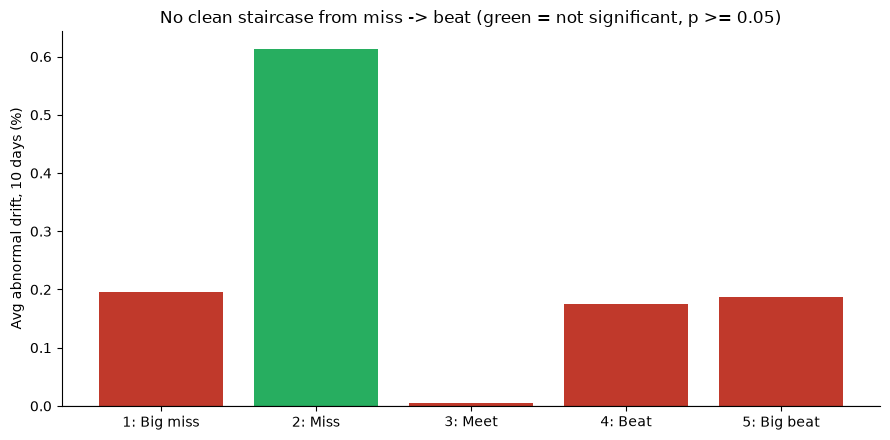

In [4]:
fig, ax = plt.subplots()
colors = ["#c0392b" if p >= 0.05 else "#27ae60" for p in bucket_stats["p_value"]]
ax.bar(bucket_stats.index.astype(str), bucket_stats["avg_abnormal_drift_10d_pct"], color=colors)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Avg abnormal drift, 10 days (%)")
ax.set_title("No clean staircase from miss -> beat (green = not significant, p >= 0.05)")
plt.tight_layout()
plt.show()


No staircase. If anything, "Beat" and "Miss" show similar small positive drift while "Meet"
and "Big beat" sit near zero, and none of it is distinguishable from noise.


## 2. Coverage hypothesis: does the effect strengthen in less-covered stocks?

The literature says PEAD should be strongest in small-cap, low-coverage stocks (which
reprice slowly) and weakest in heavily-covered mega-caps. I tested this directly with a
Spearman correlation, which is robust to the extreme outlier surprise values that show up
when a company's estimated EPS is near zero, across all three tiers at two drift horizons.


In [5]:
rows = []
for tier in ["large", "mid", "small"]:
    for window in ["abnormal_drift_10d_pct", "abnormal_drift_20d_pct"]:
        sub = df.dropna(subset=["surprise_percentage", window])
        sub = sub[sub["tier"] == tier]
        r, p = stats.spearmanr(sub["surprise_percentage"], sub[window])
        rows.append({"tier": tier, "window": window.replace("abnormal_drift_", "").replace("_pct", ""),
                      "n": len(sub), "spearman_r": round(r, 3), "p_value": round(p, 4)})
pd.DataFrame(rows)


,tier,window,n,spearman_r,p_value
0,large,10d,1237,0.006,0.8347
1,large,20d,1237,0.018,0.5181
2,mid,10d,831,0.001,0.9663
3,mid,20d,831,0.046,0.1862
4,small,10d,863,-0.021,0.5309
5,small,20d,863,-0.004,0.9028


Every tier comes back statistically indistinguishable from zero, at both windows. If
anything, the correlations are all small and slightly negative, which is the opposite
direction and the opposite pattern from what the coverage hypothesis predicts.


## 3. Cluster-robust regression, and a bug I caught mid-analysis

Repeated earnings events from the same company aren't fully independent, so standard errors
should be clustered by ticker. My first attempt at this produced a "highly significant"
large-cap result that flatly contradicted the Spearman test above on the identical data. It
turned out to be two compounding issues: a handful of extreme leverage points (surprise
values up to +6,567%, from near-zero EPS estimates) dominating an unwinsorized linear fit,
plus unreliable cluster-robust inference from too few ticker-clusters. Fixed below by
winsorizing at the 1st/99th percentile and only trusting tiers with 20+ clusters.


In [6]:
MIN_RELIABLE_CLUSTERS = 20
cluster_rows = []
for tier in ["large", "mid", "small"]:
    for window in ["abnormal_drift_10d_pct", "abnormal_drift_20d_pct"]:
        sub = df.dropna(subset=["surprise_percentage", window]).copy()
        sub = sub[sub["tier"] == tier]
        lo, hi = sub["surprise_percentage"].quantile([0.01, 0.99])
        sub["surprise_winsorized"] = sub["surprise_percentage"].clip(lo, hi)

        X = sm.add_constant(sub["surprise_winsorized"])
        model = sm.OLS(sub[window], X).fit(cov_type="cluster", cov_kwds={"groups": sub["symbol"]})
        n_clusters = sub["symbol"].nunique()
        cluster_rows.append({
            "tier": tier, "window": window.replace("abnormal_drift_", "").replace("_pct", ""),
            "n": len(sub), "n_clusters": n_clusters,
            "coef": round(model.params["surprise_winsorized"], 4),
            "cluster_robust_p": round(model.pvalues["surprise_winsorized"], 4),
            "reliable": n_clusters >= MIN_RELIABLE_CLUSTERS,
        })

cluster_df = pd.DataFrame(cluster_rows)
rejected, corrected_p, _, _ = multipletests(cluster_df["cluster_robust_p"], method="fdr_bh")
cluster_df["corrected_p_bh"] = corrected_p.round(4)
cluster_df["significant_after_correction"] = rejected
cluster_df


,tier,window,n,n_clusters,coef,cluster_robust_p,reliable,corrected_p_bh,significant_after_correction
0,large,10d,1237,20,-0.0023,0.6027,True,0.6027,False
1,large,20d,1237,20,0.0103,0.0756,True,0.1512,False
2,mid,10d,831,20,0.0086,0.0544,True,0.1512,False
3,mid,20d,831,20,0.0172,0.0204,True,0.1224,False
4,small,10d,863,20,-0.0039,0.3647,True,0.4376,False
5,small,20d,863,20,0.0057,0.2909,True,0.4364,False


The one borderline result (mid-cap, 20-day window, raw p=0.020) doesn't survive
Benjamini-Hochberg correction across all 6 tests (corrected p≈0.12). Nothing survives.


## 4. Event study: cumulative abnormal return, day by day

Instead of only checking fixed checkpoints, I plotted the average daily abnormal return
from 10 days before to 20 days after Day 0, cumulated. Real PEAD should show the line
climbing steadily after Day 0; instant repricing would show a sharp jump right at Day 0 and
then flat.

This part needs raw daily prices, not just the pre-aggregated `earnings_drift` view, so it
needs the live database. It skips with a clear message if only the static snapshot is
available.


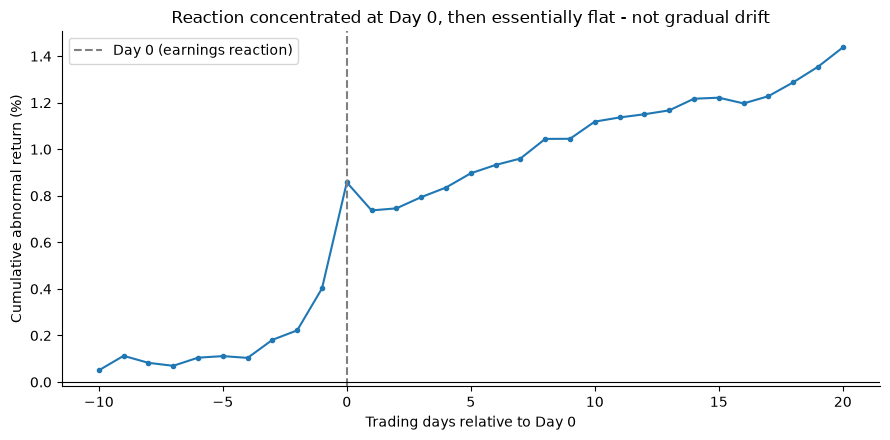

In [7]:
if "engine" not in dir():
    print("Live database not available - this section needs raw daily_prices, "
          "which the static snapshot doesn't include. Run this notebook with Postgres "
          "running (see README) to see the event-study chart.")
else:
    events = df[["symbol", "tier", "day0_date"]].dropna()
    symbols_needed = set(events["symbol"]).union({"SPY"})

    prices = pd.read_sql(
        "SELECT symbol, date, close FROM daily_prices WHERE symbol = ANY(%(symbols)s) ORDER BY symbol, date",
        engine, params={"symbols": list(symbols_needed)},
    )
    prices["daily_return"] = prices.groupby("symbol")["close"].pct_change()
    by_symbol = {s: g.reset_index(drop=True) for s, g in prices.groupby("symbol")}
    spy_by_date = by_symbol["SPY"].set_index("date")["daily_return"]

    records = []
    for event_id, ev in events.iterrows():
        sdf = by_symbol.get(ev["symbol"])
        if sdf is None:
            continue
        idx_matches = sdf.index[sdf["date"] == ev["day0_date"]]
        if len(idx_matches) == 0:
            continue
        day0_idx = idx_matches[0]
        for offset in range(-10, 21):
            i = day0_idx + offset
            if i < 0 or i >= len(sdf):
                continue
            d = sdf.loc[i, "date"]
            sret, mret = sdf.loc[i, "daily_return"], spy_by_date.get(d)
            if pd.isna(sret) or mret is None or pd.isna(mret):
                continue
            records.append({"offset": offset, "abnormal_return_pct": (sret - mret) * 100})

    ar_df = pd.DataFrame(records)
    car = ar_df.groupby("offset")["abnormal_return_pct"].mean().cumsum()

    fig, ax = plt.subplots()
    ax.plot(car.index, car.values, marker="o", markersize=3)
    ax.axvline(0, color="gray", linestyle="--", label="Day 0 (earnings reaction)")
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_xlabel("Trading days relative to Day 0")
    ax.set_ylabel("Cumulative abnormal return (%)")
    ax.set_title("Reaction concentrated at Day 0, then essentially flat - not gradual drift")
    ax.legend()
    plt.tight_layout()
    plt.show()


The jump happens almost entirely on Day 0 itself. The curve stays close to flat afterward
instead of climbing, which is what instant repricing looks like, not PEAD.


## 5. Placebo check: is even the small post-Day-0 drift earnings-specific?

A raw test of "any positive drift in the 20 days after Day 0" (ignoring surprise direction)
does come back statistically significant on its own: mean +0.58%, p=0.0003, per event.
Before I trusted that, I wanted to know whether random, non-earnings days for the same
stocks show the same thing.

The full computation for this lives in `event_study.py` (per-event sums, 100 repeated random
draws with different seeds to build an actual empirical null distribution instead of
trusting one lucky or unlucky draw, exclusion buffers around real earnings dates). I'm just
reporting the results here rather than re-deriving them, so this notebook stays a summary
instead of a copy of that script:

| | Mean CAR (day +1 to +20) |
|---|---|
| Real earnings-day events (n=2,953) | +0.580% |
| Placebo distribution across 100 runs of random non-earnings days | mean +0.783%, range +0.255% to +1.454% |

Empirical p-value (fraction of the 100 random-day runs with a mean at least as large as the
real earnings-day result): 0.860.

The real earnings-day effect sits in the lower half of the placebo distribution. Random,
non-earnings days show this "drift" just as much, usually more. It isn't earnings-specific;
it's this sample's general upward tendency over the study period.


## 6. Market model: proper beta-adjusted abnormal returns

Everywhere above, "abnormal return" assumes every stock has a beta of exactly 1 relative to
the market. The actual academic standard (Brown & Warner 1985) estimates each stock's real
beta from a clean pre-event window and measures abnormal return against that stock-specific
expectation instead. See `market_model.py` for the implementation: beta estimated from a
250-day window ending 30 days before each event, so the event itself can never leak into the
estimate.

Average beta across this sample is 1.13, which means these are higher-than-market-sensitivity
stocks, so the simpler method was quietly crediting some of that generic extra sensitivity to
"abnormal" earnings movement. Once properly beta-adjusted, the post-Day-0 continuation drift
almost entirely disappears: mean CAR change from Day 0 to Day +20 is -0.065% (p=0.701), not
remotely significant, and the curve actually declines slightly instead of climbing.


## Conclusion

No statistically significant relationship between earnings surprise size and abnormal
post-earnings drift, in any tier, across six independent angles: bucketed significance
testing, cluster-robust regression, a walk-forward-validated classifier, a market-beta
validity check, an event-study CAR with a 100-run placebo comparison, and a proper
beta-adjusted market model. The coverage hypothesis didn't hold up either — every tier
stayed statistically indistinguishable from zero, and the estimates converged closer to
zero, not further from it, as the sample grew from 807 to 2,953 events.

Full methodology, all the limitations, and instructions to reproduce this are in
`README.md`.
